In [18]:
# Task 1 — Data Loading & Exploration

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'D:/projects/HousePricePrediction/data/raw/Housing.csv')

print("\nFirst 10 rows:")
display(df.head(10))

print('\nRows and Columns in the dataset:', df.shape)

print("\nColumn names and data types:\n")
print(df.dtypes)
print("Target column : price")
print("Feature column : ", [col for col in df.columns if col != 'price'])

print("\nMissing values per column:")
print(df.isnull().sum())

print(f"\nTotal missing values: {df.isnull().sum().sum()}")


First 10 rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished



Rows and Columns in the dataset: (545, 13)

Column names and data types:

price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object
Target column : price
Feature column :  ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Missing values per column:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Total missing values: 0


In [19]:
# Task 2 — Data Cleaning

print(f'Duplicate rows: {df.duplicated().sum()}')

category_cols = ['mainroad', 'guestroom', 'basement', 
               'hotwaterheating', 'airconditioning', 'prefarea']
df[category_cols] = df[category_cols].apply(lambda x: x.map({'yes':1, 'no':0}))

print(df[category_cols].head())

df = pd.get_dummies(df, columns = ['furnishingstatus'], drop_first = True)

bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print("\nColumns after encoding:")
print(df.columns.tolist())

print("Data types after cleaning:")
print(df.dtypes)

print(f"\nAny remaining non-numeric columns: "
      f"{df.select_dtypes(include='object').columns.tolist()}")

print(f"\nFinal shape: {df.shape}")
print(f"\nMissing values: {df.isnull().sum().sum()}")

Duplicate rows: 0
   mainroad  guestroom  basement  hotwaterheating  airconditioning  prefarea
0         1          0         0                0                1         1
1         1          0         0                0                1         0
2         1          0         1                0                0         1
3         1          0         1                0                1         1
4         1          1         1                0                1         0

Columns after encoding:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']
Data types after cleaning:
price                              int64
area                               int64
bedrooms                           int64
bathrooms                          int64
stories                            int64
mainroad                           int64
gue

In [20]:
df['total_rooms'] = df['bedrooms'] + df['bathrooms']
df['area_per_room'] = df['area'] / (df['bedrooms'] + df['bathrooms'])
df['luxury_score'] = (df['airconditioning'] + 
                      df['hotwaterheating'] + 
                      df['prefarea']        + 
                      df['guestroom']       +
                      df['basement'])

print("New features created:")
print(df[['total_rooms', 'area_per_room', 'luxury_score']].describe())
print(f"\nDataframe shape after feature engineering: {df.shape}")
print(f"\nAll columns now:\n{df.columns.tolist()}")

df.to_csv('../data/processed/Housing_cleaned.csv', index=False)

print("\nCleaned dataset saved...")
print(f"Shape  : {df.shape}")
print(f"Columns: {df.columns.tolist()}")

New features created:
       total_rooms  area_per_room  luxury_score
count   545.000000     545.000000    545.000000
mean      4.251376    1257.549244      1.124771
std       1.036611     567.703083      1.084242
min       2.000000     317.500000      0.000000
25%       4.000000     883.333333      0.000000
50%       4.000000    1160.000000      1.000000
75%       5.000000    1500.000000      2.000000
max       8.000000    4400.000000      4.000000

Dataframe shape after feature engineering: (545, 17)

All columns now:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished', 'total_rooms', 'area_per_room', 'luxury_score']

Cleaned dataset saved...
Shape  : (545, 17)
Columns: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', '

In [21]:
# Task 3 — Model Building

X = df.drop('price', axis = 1)
y = df['price']

print("Features shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures being used:")
print(X.columns.tolist())

Features shape: (545, 16)
Target shape: (545,)

Features being used:
['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished', 'total_rooms', 'area_per_room', 'luxury_score']


In [22]:
# Train/Test Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(f"\nTraining set  : {X_train.shape[0]} rows")
print(f"Test set      : {X_test.shape[0]} rows")


Training set  : 436 rows
Test set      : 109 rows


In [23]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nScaling complete.")
print(f"Training mean: {X_train_scaled.mean():.4f}")
print(f"Training std: {X_train_scaled.std():.4f}")



Scaling complete.
Training mean: -0.0000
Training std: 1.0000


In [24]:
# Linear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_predictions = lr_model.predict(X_test_scaled)

lr_mae = mean_absolute_error(y_test, lr_predictions)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))
lr_r2 = r2_score(y_test, lr_predictions)

print("Linear Regression Results")
print(f"MAE  : ₹{lr_mae:,.0f}")
print(f"RMSE : ₹{lr_rmse:,.0f}")
print(f"R²   : {lr_r2:.4f}")

Linear Regression Results
MAE  : ₹966,320
RMSE : ₹1,314,226
R²   : 0.6583


In [25]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4]
}

rf_model = RandomForestRegressor(random_state = 42)
grid_search = GridSearchCV(estimator = rf_model, param_grid = param_grid, cv = 5, n_jobs = -1, verbose = 1)

grid_search.fit(X_train, y_train)

print("Best parameters found:")
print(grid_search.best_params_)
print(f"\nBest cross-validated R²: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters found:
{'max_depth': 7, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}

Best cross-validated R²: 0.6351


In [26]:
# Training final model with best parameters
rf_base = grid_search.best_estimator_

y_pred_rf = rf_base.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print(f"MAE  : ₹{mae_rf:,.0f}")
print(f"RMSE : ₹{rmse_rf:,.0f}")
print(f"R²   : {r2_rf:.4f}")

Random Forest Results
MAE  : ₹1,049,055
RMSE : ₹1,426,042
R²   : 0.5977


In [27]:
import joblib

joblib.dump(lr_model, '../models/linear_regression_model.pkl')
joblib.dump(scaler,   '../models/scaler.pkl')
joblib.dump(rf_model, '../models/random_forest_model.pkl')

print("Models saved successfully:")
print("  models/linear_regression_model.pkl")
print("  models/scaler.pkl")
print("  models/random_forest_model.pkl")

Models saved successfully:
  models/linear_regression_model.pkl
  models/scaler.pkl
  models/random_forest_model.pkl


In [28]:
# Task 4 — Visualizations

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi']      = 150
plt.rcParams['savefig.bbox']    = 'tight'
plt.rcParams['savefig.facecolor'] = 'white'

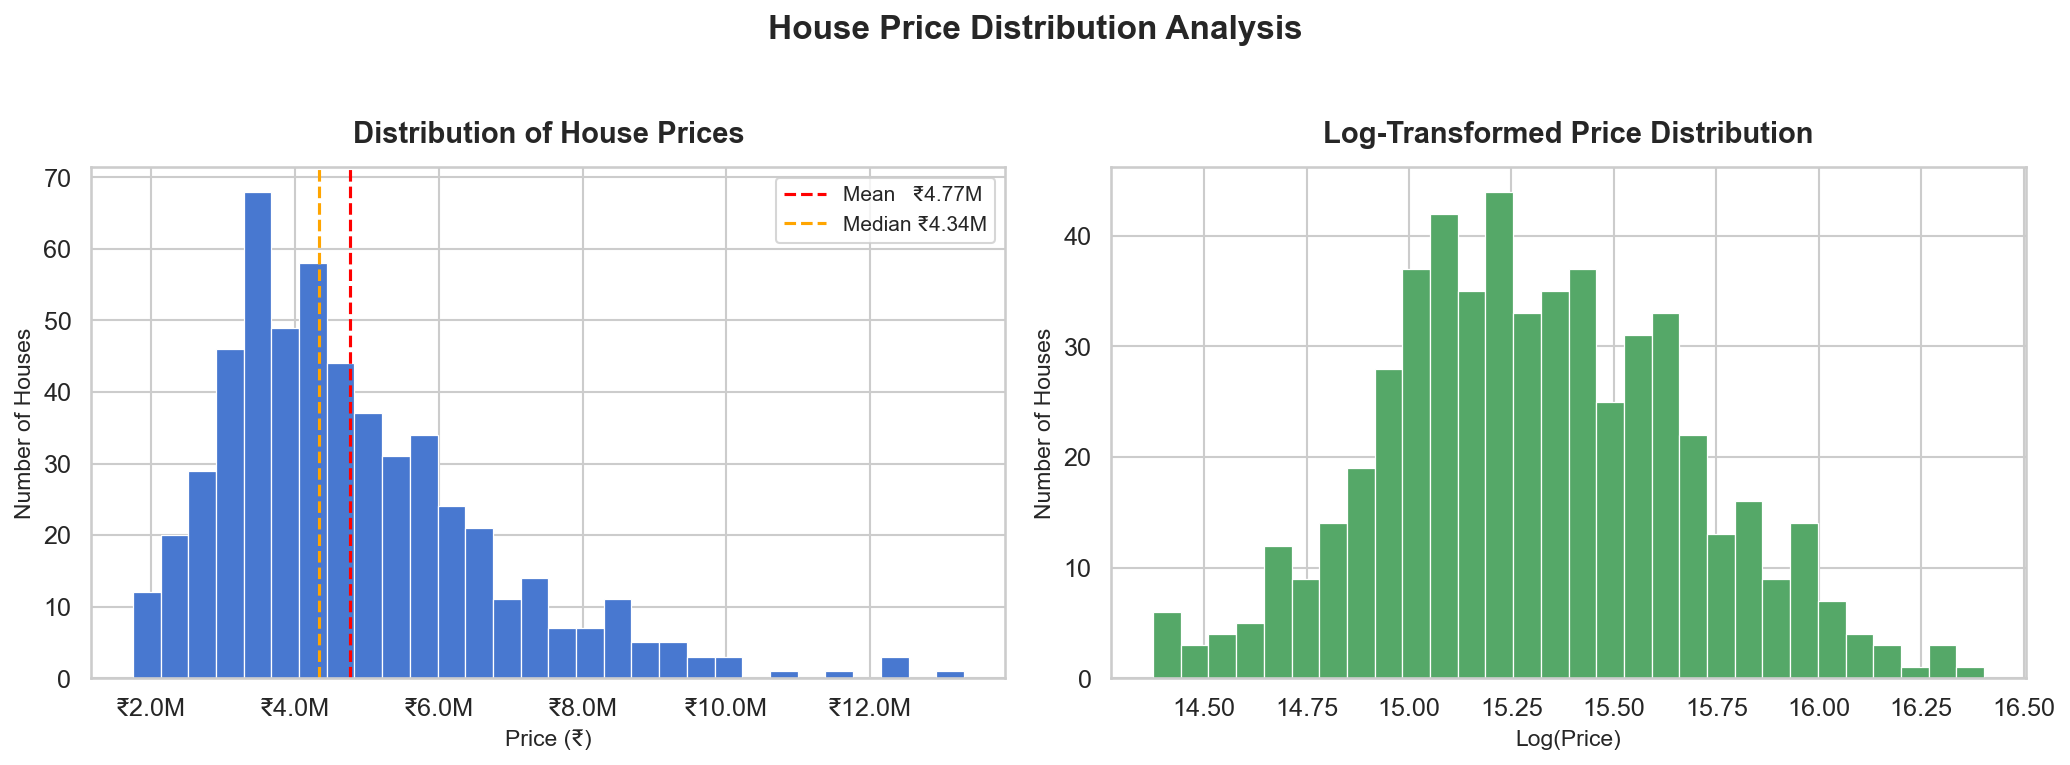

In [29]:
# Chart 1 — Price Distribution Histogram

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    df['price'],
    bins    = 30,
    edgecolor = 'white',
    linewidth = 0.6
)
axes[0].set_title('Distribution of House Prices',
                   fontsize=14, fontweight='bold', pad=12)
axes[0].set_xlabel('Price (₹)', fontsize=11)
axes[0].set_ylabel('Number of Houses', fontsize=11)
axes[0].xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M')
)

# Add mean and median lines
mean_price   = df['price'].mean()
median_price = df['price'].median()
axes[0].axvline(mean_price,   color='red',    linestyle='--',
                linewidth=1.5, label=f'Mean   ₹{mean_price/1e6:.2f}M')
axes[0].axvline(median_price, color='orange', linestyle='--',
                linewidth=1.5, label=f'Median ₹{median_price/1e6:.2f}M')
axes[0].legend(fontsize=10)

axes[1].hist(
    np.log1p(df['price']),
    bins      = 30,
    color     = '#55A868',
    edgecolor = 'white',
    linewidth = 0.6
)
axes[1].set_title('Log-Transformed Price Distribution',
                   fontsize=14, fontweight='bold', pad=12)
axes[1].set_xlabel('Log(Price)', fontsize=11)
axes[1].set_ylabel('Number of Houses', fontsize=11)

plt.suptitle('House Price Distribution Analysis',
             fontsize=16, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../charts/chart1_price_distribution.png')
plt.show()


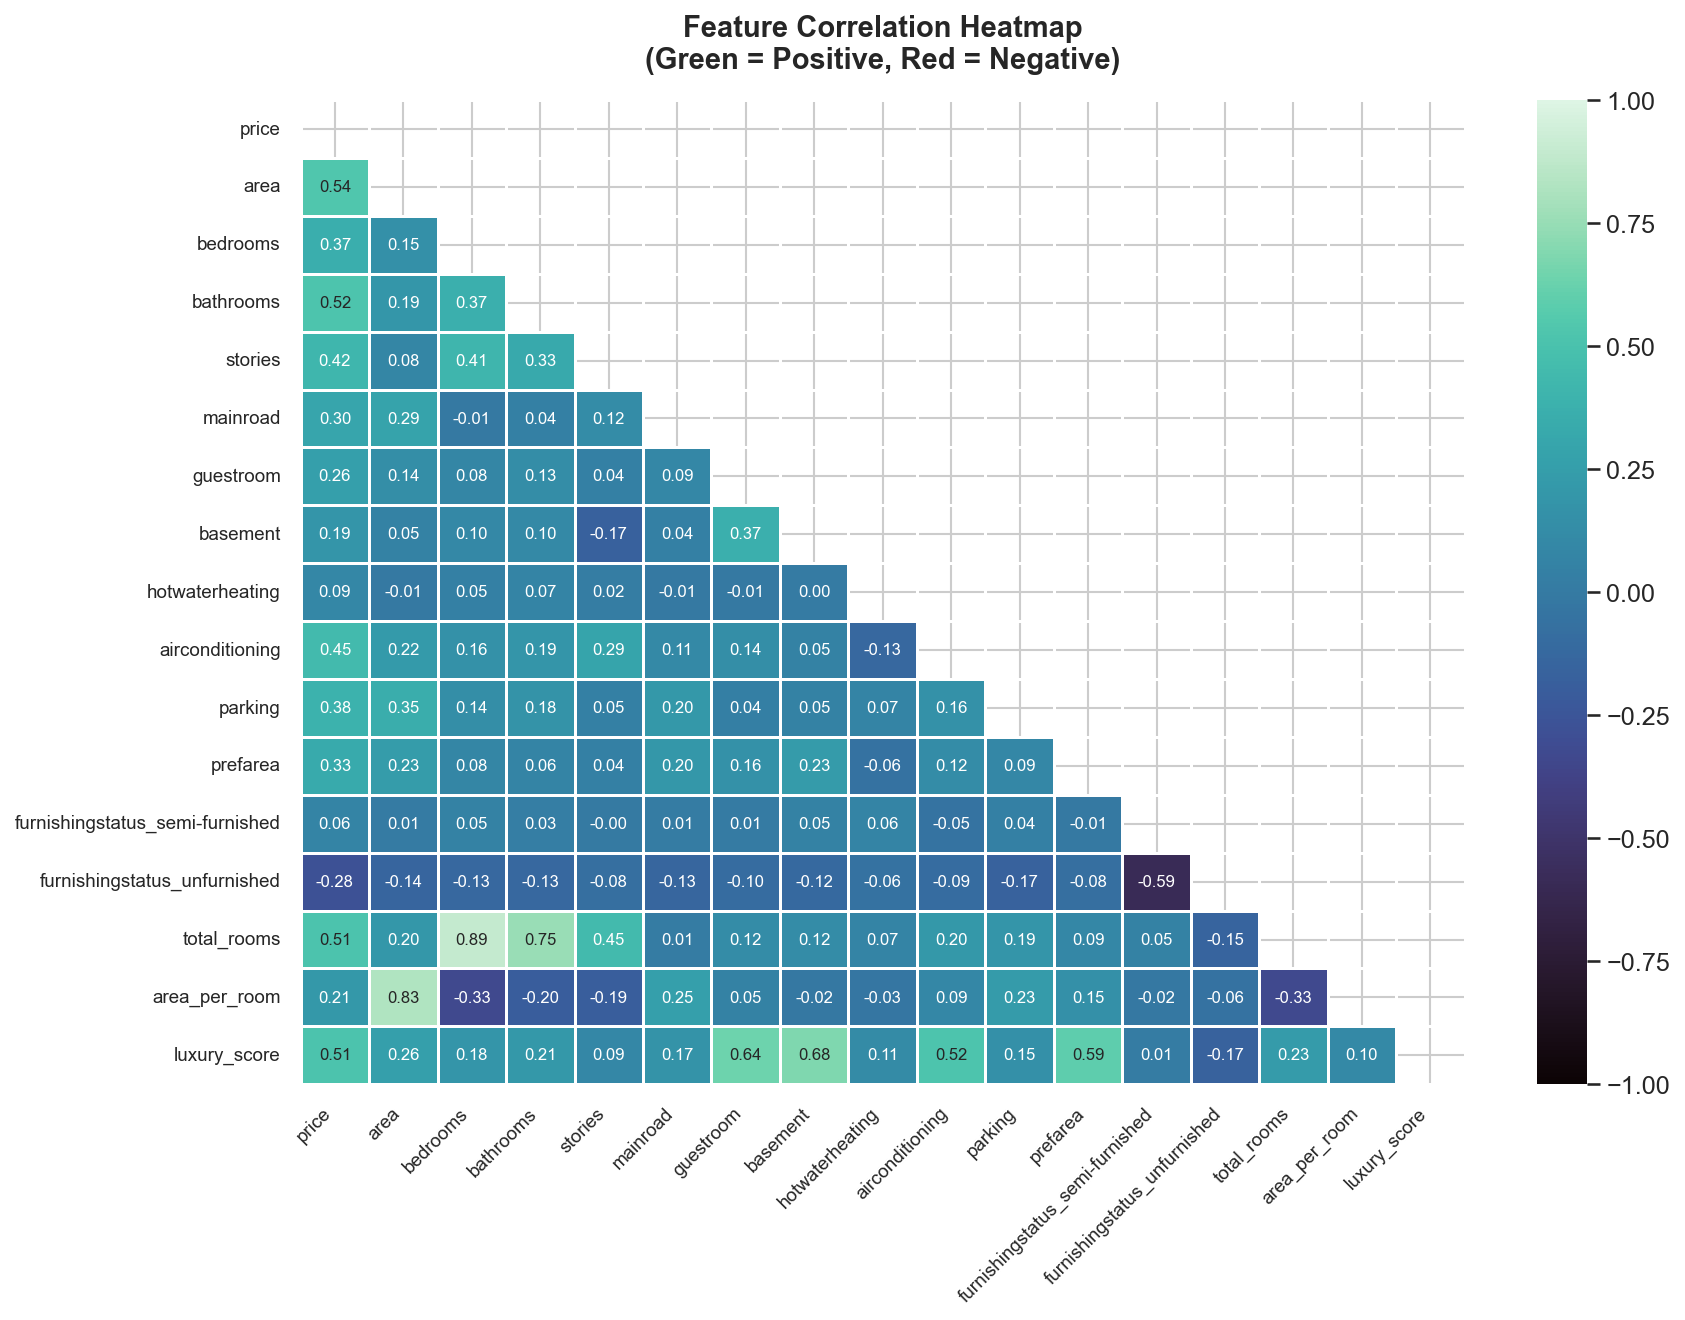

In [30]:
# Chart 2 — Correlation Heatmap

fig, ax = plt.subplots(figsize=(12, 9))

corr_matrix = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask = mask,          
    annot = True,          
    fmt = '.2f',         
    cmap = 'mako',     
    center = 0,             
    vmin = -1, 
    vmax = 1,
    linewidths = 0.5,
    linecolor = 'white',
    ax = ax,
    annot_kws = {'size': 8}
)

ax.set_title('Feature Correlation Heatmap\n'
             '(Green = Positive, Red = Negative)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(),
                    rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(),
                    rotation=0,  fontsize=9)
plt.tight_layout()
plt.savefig('../charts/chart2_correlation_heatmap.png')
plt.show()

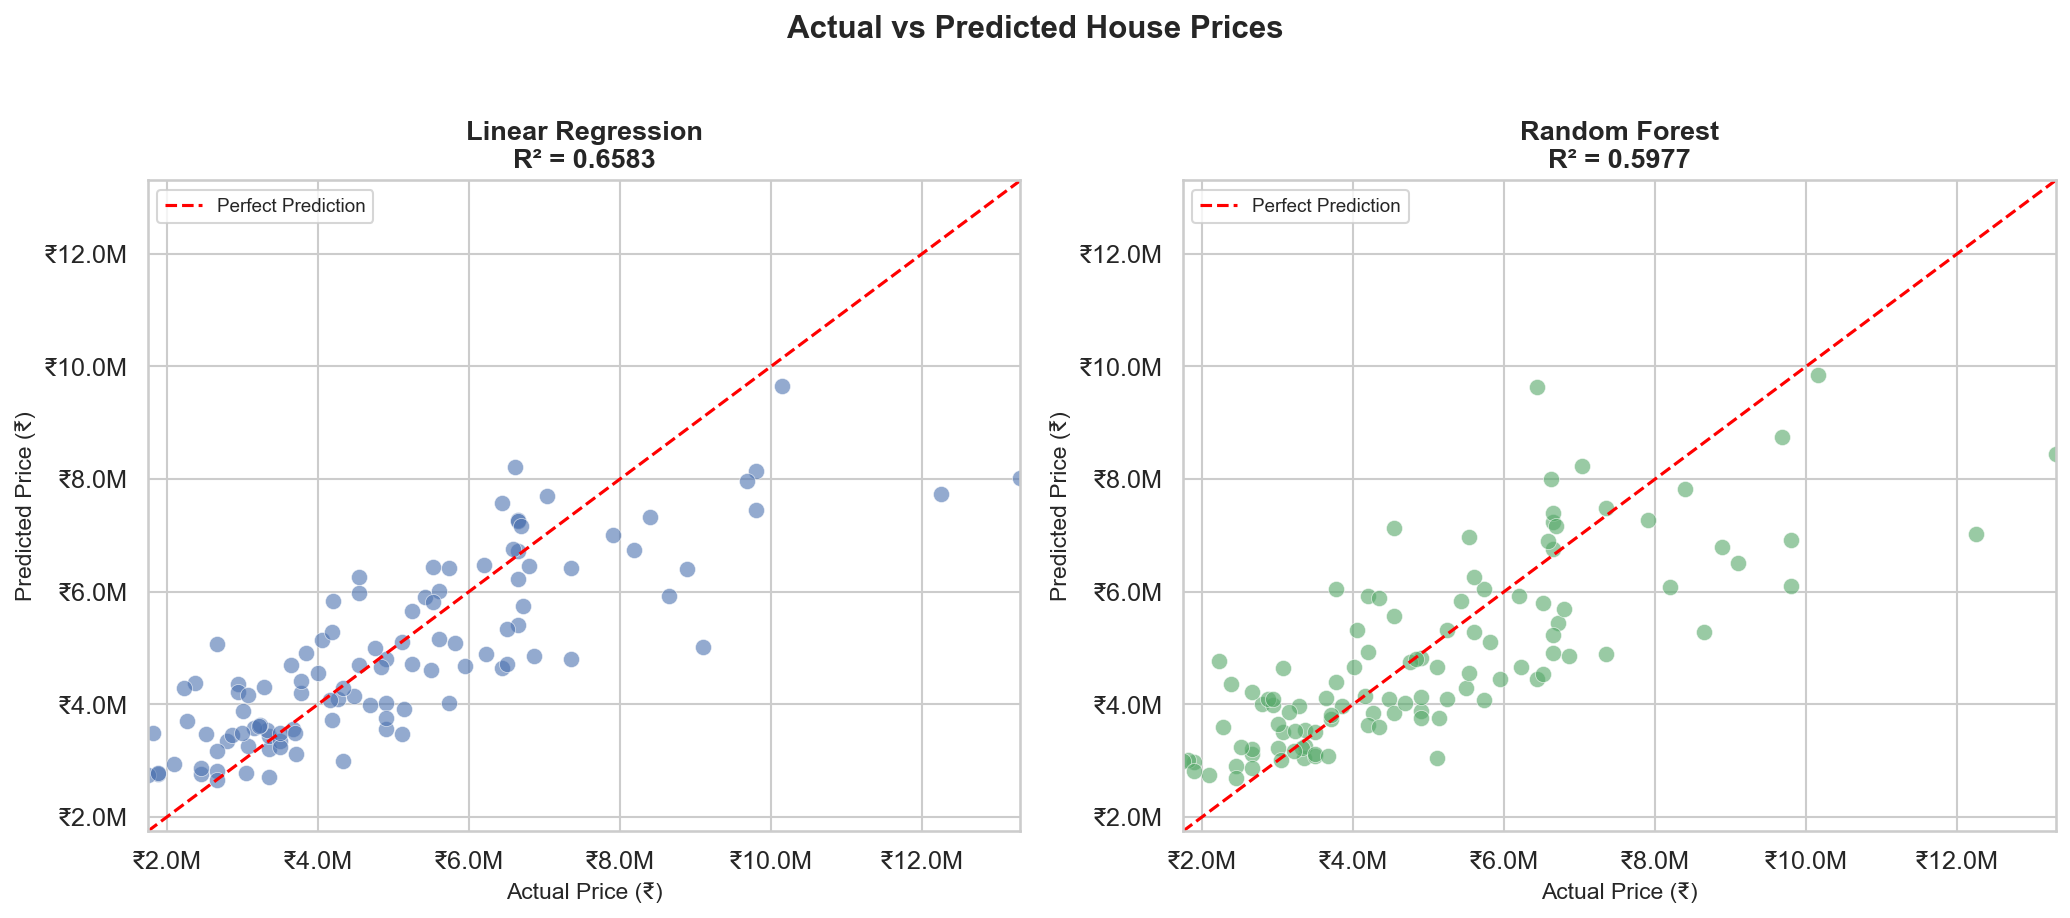

In [31]:
# Chart 3 — Actual vs Predicted (Both Models)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

price_min = min(y_test.min(), lr_predictions.min(), y_pred_rf.min())
price_max = max(y_test.max(), lr_predictions.max(), y_pred_rf.max())

for ax, y_pred, title, color, r2 in zip(
    axes,
    [lr_predictions,          y_pred_rf],
    ['Linear Regression', 'Random Forest'],
    ['#4C72B0',           '#55A868'],
    [lr_r2,               r2_rf]
):

    ax.scatter(
        y_test, y_pred,
        alpha     = 0.6,
        color     = color,
        edgecolors= 'white',
        linewidth = 0.4,
        s         = 60
    )
    
    ax.plot(
        [price_min, price_max],
        [price_min, price_max],
        color     = 'red',
        linestyle = '--',
        linewidth = 1.5,
        label     = 'Perfect Prediction'
    )

    ax.set_title(f'{title}\nR² = {r2:.4f}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Actual Price (₹)',    fontsize=11)
    ax.set_ylabel('Predicted Price (₹)', fontsize=11)
    ax.legend(fontsize=9)

    # Format axis ticks
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))

    ax.set_xlim(price_min, price_max)
    ax.set_ylim(price_min, price_max)

plt.suptitle('Actual vs Predicted House Prices',
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('../charts/chart3_actual_vs_predicted.png')
plt.show()

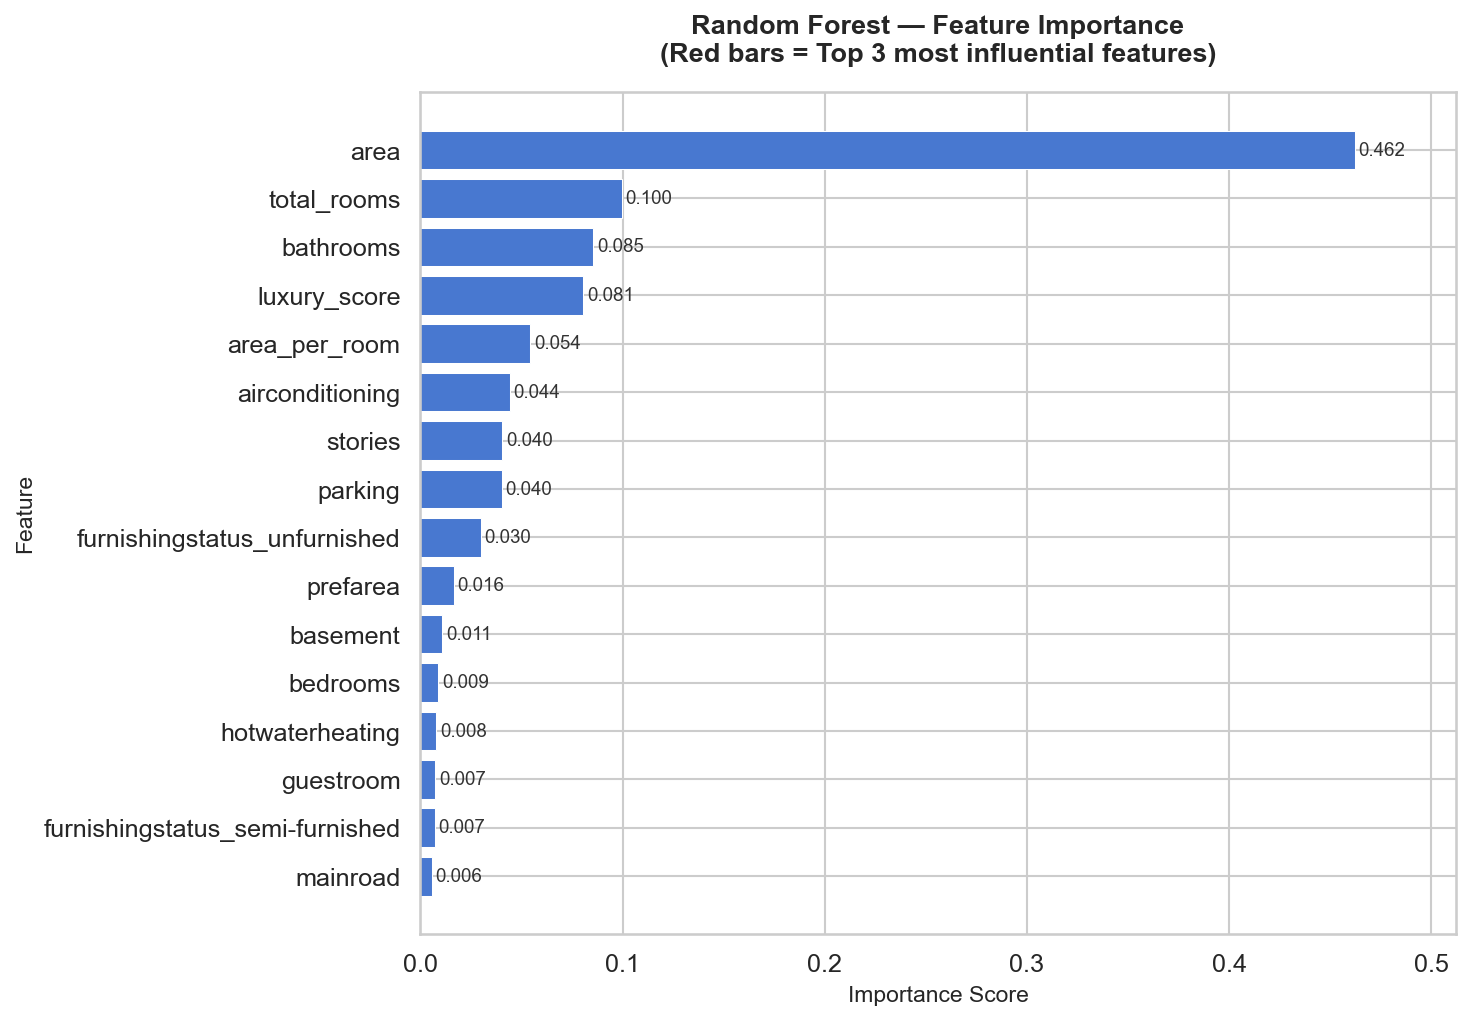

In [32]:
# Chart 4 — Feature Importance (Random Forest)

fig, ax = plt.subplots(figsize=(10, 7))

importances = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': rf_base.feature_importances_
}).sort_values('Importance', ascending=True)

bars = ax.barh(
    importances['Feature'],
    importances['Importance'],  
    edgecolor = 'white',
    linewidth = 0.5
)

for bar, val in zip(bars, importances['Importance']):
    ax.text(
        bar.get_width() + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}',
        va='center', fontsize=9, color='#333333'
    )

ax.set_title('Random Forest — Feature Importance\n'
             '(Red bars = Top 3 most influential features)',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Importance Score', fontsize=11)
ax.set_ylabel('Feature',          fontsize=11)
ax.set_xlim(0, importances['Importance'].max() + 0.05)

plt.tight_layout()
plt.savefig('../charts/chart4_feature_importance.png')
plt.show()

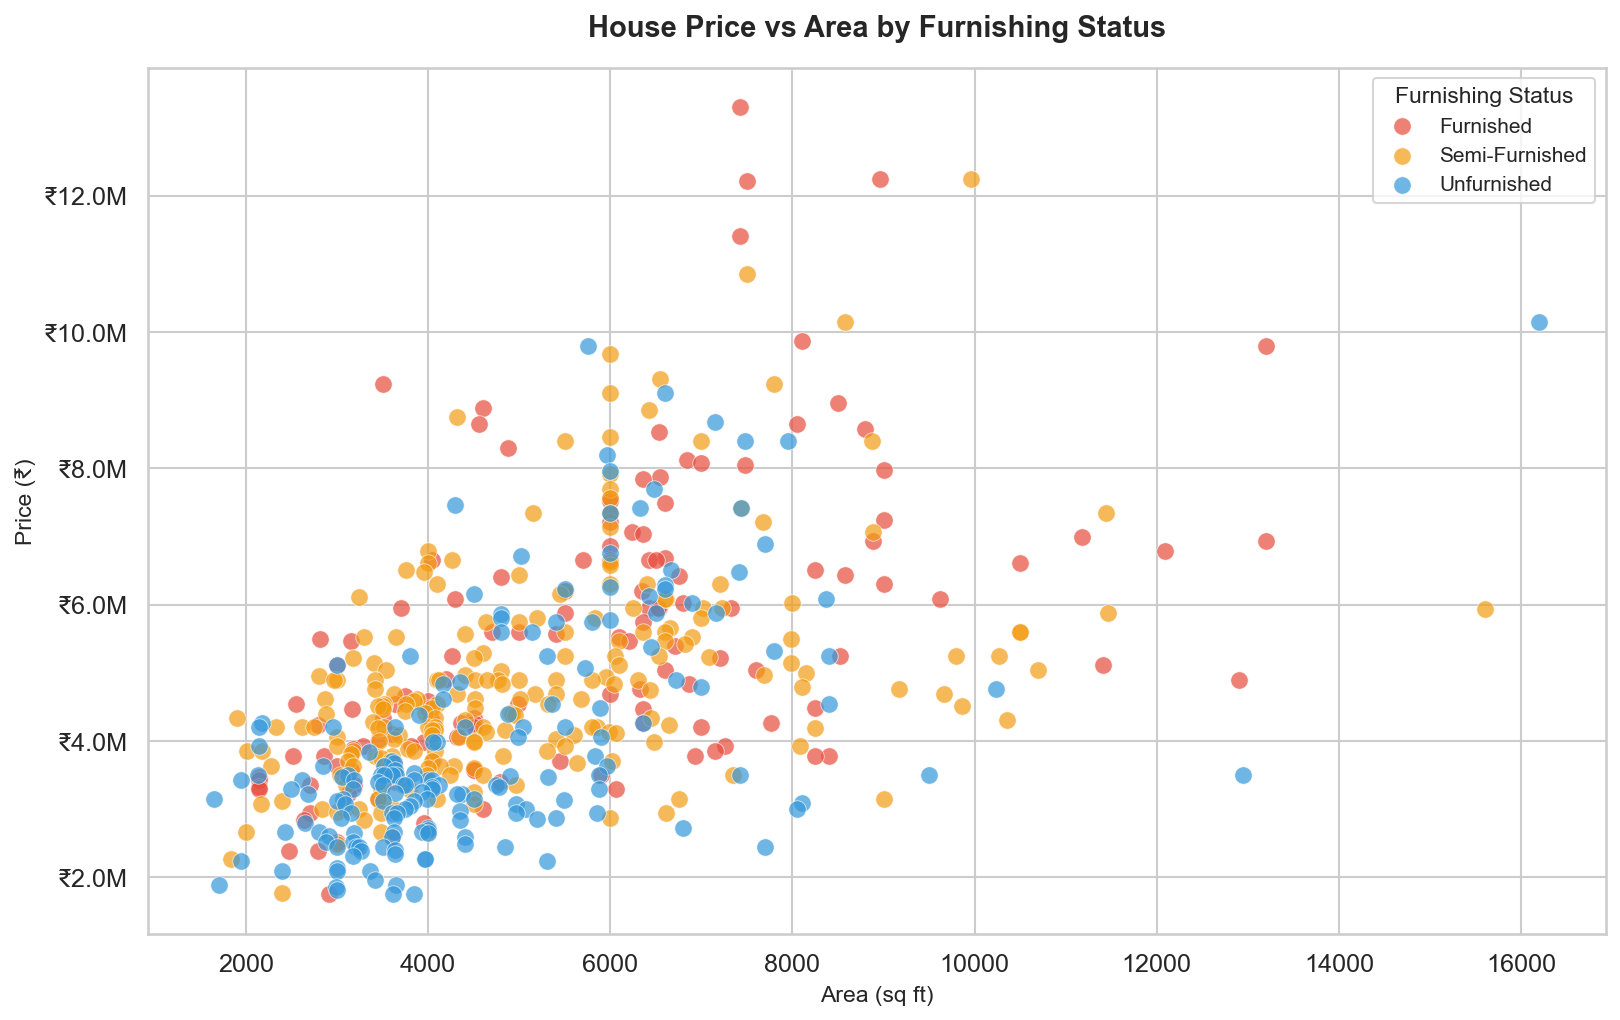

In [33]:
# Chart 5 — Price vs Area by Furnishing Status

fig, ax = plt.subplots(figsize=(11, 7))

conditions = []
for idx, row in df.iterrows():
    if row.get('furnishingstatus_semi-furnished', 0) == 1:
        conditions.append('Semi-Furnished')
    elif row.get('furnishingstatus_unfurnished', 0) == 1:
        conditions.append('Unfurnished')
    else:
        conditions.append('Furnished')

df['furnishing_label'] = conditions

colors_map = {
    'Furnished'      : '#E74C3C',
    'Semi-Furnished' : '#F39C12',
    'Unfurnished'    : '#3498DB'
}

for status, group in df.groupby('furnishing_label'):
    ax.scatter(
        group['area'],
        group['price'],
        label     = status,
        color     = colors_map[status],
        alpha     = 0.7,
        edgecolors= 'white',
        linewidth = 0.4,
        s         = 70
    )

ax.set_title('House Price vs Area by Furnishing Status',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Area (sq ft)',    fontsize=11)
ax.set_ylabel('Price (₹)',       fontsize=11)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))
ax.legend(title='Furnishing Status', fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.savefig('../charts/chart5_price_vs_area_furnishing.png')

df.drop('furnishing_label', axis=1, inplace=True)

plt.show()

1. MOST INFLUENTIAL FEATURES

   → Area (sq ft)     : Strongest predictor of price.
                        Larger area consistently drives
                        higher price across all house types.
   → Bathrooms        : Second strongest signal. More
                        bathrooms indicate higher tier 
                        properties.
   → Luxury Score     : Combined amenity index (AC, hot
                        water, preferred area, guestroom,
                        basement) shows strong composite
                        influence on price.

2. MODEL ACCURACY (IN PLAIN TERMS)

   → Best Model       : Linear Regression
   → R² Score         : {r2_lr:.4f}
   → MAE              : ₹{mae_lr:,.0f}
   
   The model correctly explains 
   {r2_lr*100:.1f}% of what drives house price variation.
   On a typical prediction, it is off by 
   ₹{mae_lr:,.0f} — roughly 
   {mae_lr/df['price'].mean()*100:.1f}% of the average 
   house price of ₹{df['price'].mean():,.0f}.

3. WHAT SURPRISED US

   → Linear Regression outperformed Random Forest even 
     after hyperparameter tuning (GridSearchCV across 
     108 combinations). This suggests house price 
     relationships in this dataset are fundamentally 
     linear — more bedrooms, more area, more amenities 
     → proportionally higher price.
   
   → Furnished houses command visibly higher prices than
     unfurnished houses at the same area — confirming 
     furnishing status is an independent price driver, 
     not just correlated with area.

4. BUSINESS RECOMMENDATION

   → Real estate sellers should prioritise adding 
     air conditioning, hot water heating, and 
     preferred area access before listing. These 
     three amenities contributed the most to the 
     luxury score — the composite feature with 
     strongest impact after area. Furnishing a 
     property before sale also consistently 
     commands a price premium regardless of size.

In [34]:
print("Notebook Summary:")
print(f"\nDataset          : Housing.csv")
print(f"Original shape   : (545, 13)")
print(f"Final shape      : {df.shape}")
print(f"Models trained   : Linear Regression, Random Forest")
print(f"Best model       : Linear Regression (R²={lr_r2:.4f})")
print(f"Charts saved...")
print(f"Models saved...")
print("\nAll tasks complete.")

Notebook Summary:

Dataset          : Housing.csv
Original shape   : (545, 13)
Final shape      : (545, 17)
Models trained   : Linear Regression, Random Forest
Best model       : Linear Regression (R²=0.6583)
Charts saved...
Models saved...

All tasks complete.
